In [1]:
# Section 1: Import libraries
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


In [28]:
import flask
import joblib
import numpy
import pandas
import sklearn

print("--- Library Versions ---")
print(f"Flask:         {flask.__version__}")
print(f"Joblib:        {joblib.__version__}")
print(f"NumPy:         {numpy.__version__}")
print(f"Pandas:        {pandas.__version__}")
print(f"Scikit-learn:  {sklearn.__version__}")
print("------------------------")

--- Library Versions ---
Flask:         3.1.1
Joblib:        1.4.2
NumPy:         2.1.3
Pandas:        2.2.3
Scikit-learn:  1.6.1
------------------------


In [2]:
# Section 2: Load dataset
data_path = "D:\CODING\Python\Heart Disese Prediction\heart.csv"  # update path if needed
df = pd.read_csv(data_path)
df.columns = [c.strip().lower() for c in df.columns]

# Rename num -> target if needed
if "num" in df.columns and "target" not in df.columns:
    df = df.rename(columns={"num": "target"})

# Binarize target if >2 classes
if df["target"].nunique() > 2:
    df["target"] = (df["target"] > 0).astype(int)

print("✅ Dataset loaded successfully!")
print(df.head())


✅ Dataset loaded successfully!
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
# Section 3: Quick EDA
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df["target"].value_counts(normalize=True))


Shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target distribution:
 target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [5]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # Changed here
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric),
    ("cat", categorical_transformer, categorical)
])


In [6]:
# Section 5: Train/test split
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (820, 13)
Test shape: (205, 13)


In [7]:
# Section 6: Define models & parameter grids

# Logistic Regression
pipe_log = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))
])
param_grid_log = {"clf__C": [0.01, 0.1, 1.0, 10.0]}

# Random Forest
pipe_rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])
param_grid_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 6, 12],
    "clf__min_samples_leaf": [1, 2, 4]
}


In [8]:
# Section 7: Train with GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Training Logistic Regression...")
gs_log = GridSearchCV(pipe_log, param_grid=param_grid_log, scoring="roc_auc", cv=cv, n_jobs=-1)
gs_log.fit(X_train, y_train)

print("Best Logistic Regression params:", gs_log.best_params_)
print("Best CV ROC AUC:", gs_log.best_score_)

print("\nTraining Random Forest...")
gs_rf = GridSearchCV(pipe_rf, param_grid=param_grid_rf, scoring="roc_auc", cv=cv, n_jobs=-1)
gs_rf.fit(X_train, y_train)

print("Best Random Forest params:", gs_rf.best_params_)
print("Best CV ROC AUC:", gs_rf.best_score_)

# Choose best
best_gs = gs_log if gs_log.best_score_ >= gs_rf.best_score_ else gs_rf
best_name = "LogisticRegression" if best_gs is gs_log else "RandomForest"
final_model = best_gs.best_estimator_

print(f"\n✅ Best model selected: {best_name}")


Training Logistic Regression...
Best Logistic Regression params: {'clf__C': 1.0}
Best CV ROC AUC: 0.9251078121121867

Training Random Forest...
Best Random Forest params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
Best CV ROC AUC: 0.9985565476190477

✅ Best model selected: RandomForest


Test Accuracy: 1.0
Test ROC AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion Matrix:
 [[100   0]
 [  0 105]]


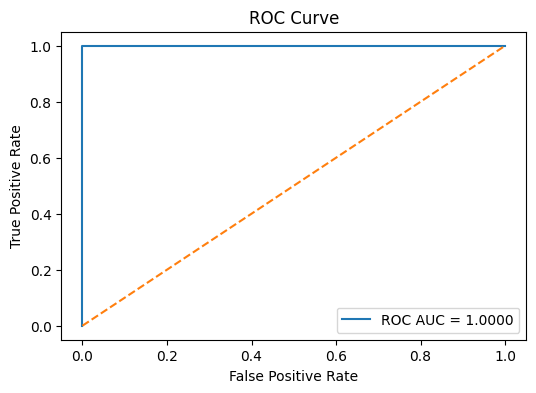

In [9]:
# Section 8: Evaluate on test set
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Test Accuracy:", acc)
print("Test ROC AUC:", auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [10]:
# Section 9: Save trained model + schema
os.makedirs("output", exist_ok=True)

joblib.dump(final_model, "output/best_pipeline.pkl")

schema = {
    "features": X.columns.tolist(),
    "numeric": numeric,
    "categorical": categorical,
    "selected_model": best_name,
    "cv_score": float(best_gs.best_score_)
}
with open("output/schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("✅ Model and schema saved in /output")


✅ Model and schema saved in /output


In [14]:
# --- Example prediction on one sample ---

# 1. Select a sample (e.g., the 5th row of the test data)
sample = X_test.iloc[[4]] 
print("Input Features for the Sample:\n", sample)

# 2. Get the probability for the positive class (class 1)
# The output of predict_proba is [[prob_class_0, prob_class_1]]
# We select [0, 1] to get the probability of heart disease
prob_heart_disease = final_model.predict_proba(sample)[0, 1]

# 3. Get the final predicted class (0 or 1)
prediction = final_model.predict(sample)[0]

# 4. Map the prediction to a human-readable label
prediction_label = "Heart Disease" if prediction == 1 else "No Heart Disease"

# 5. Display the results
print(f"\nChance of Heart Disease: {prob_heart_disease * 100:.2f}%")
print(f"Final Prediction: {prediction_label} (Class {prediction})")

Input Features for the Sample:
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
591   63    0   0       108   269    0        1      169      1      1.8   

     slope  ca  thal  
591      1   2     2  

Chance of Heart Disease: 0.67%
Final Prediction: No Heart Disease (Class 0)


In [24]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# Load the trained model
model = joblib.load("D:\CODING\Python\Heart Disese Prediction\Heart Disease.pkl")

st.set_page_config(page_title="❤️ Heart Disease Prediction", layout="centered")

st.title("❤️ Heart Disease Prediction App")
st.write("Fill in the details below to check the risk of heart disease.")

# Sidebar for input features
st.sidebar.header("Patient Information")

def user_input_features():
    age = st.sidebar.slider("Age", 18, 100, 50)
    sex = st.sidebar.selectbox("Sex", ("Male", "Female"))
    cp = st.sidebar.selectbox("Chest Pain Type (0-3)", [0,1,2,3])
    trestbps = st.sidebar.slider("Resting Blood Pressure", 80, 200, 120)
    chol = st.sidebar.slider("Serum Cholesterol (mg/dl)", 100, 600, 200)
    fbs = st.sidebar.selectbox("Fasting Blood Sugar > 120 mg/dl", [0,1])
    restecg = st.sidebar.selectbox("Resting ECG (0-2)", [0,1,2])
    thalach = st.sidebar.slider("Max Heart Rate Achieved", 70, 220, 150)
    exang = st.sidebar.selectbox("Exercise Induced Angina", [0,1])
    oldpeak = st.sidebar.slider("ST Depression (Oldpeak)", 0.0, 6.0, 1.0)
    slope = st.sidebar.selectbox("Slope of Peak Exercise ST Segment", [0,1,2])
    ca = st.sidebar.selectbox("Number of Major Vessels (0-4)", [0,1,2,3,4])
    thal = st.sidebar.selectbox("Thalassemia (0=Normal, 1=Fixed Defect, 2=Reversible Defect)", [0,1,2])

    # Convert to DataFrame
    data = {
        "age": age,
        "sex": 1 if sex == "Male" else 0,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal,
    }
    features = pd.DataFrame(data, index=[0])
    return features

input_df = user_input_features()

st.subheader("📋 Patient Data")
st.write(input_df)

# Prediction
if st.button("🔍 Predict"):
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.error(f"⚠️ High Risk of Heart Disease! (Probability: {probability:.2f})")
    else:
        st.success(f"✅ Low Risk of Heart Disease (Probability: {probability:.2f})")


2025-09-05 17:08:15.538 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.549 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-05 17:08:15.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

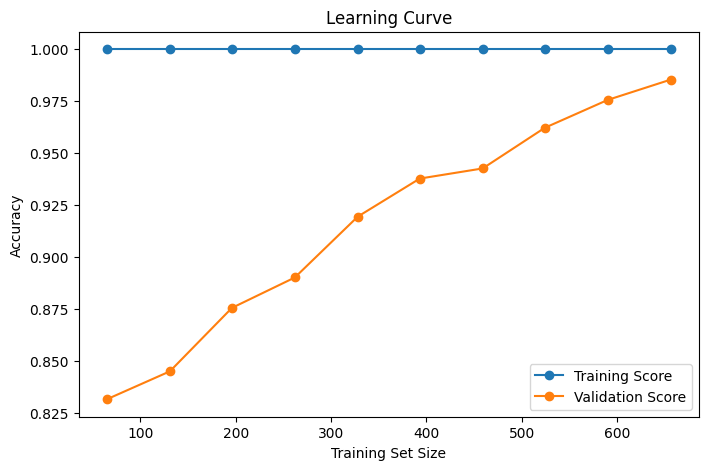

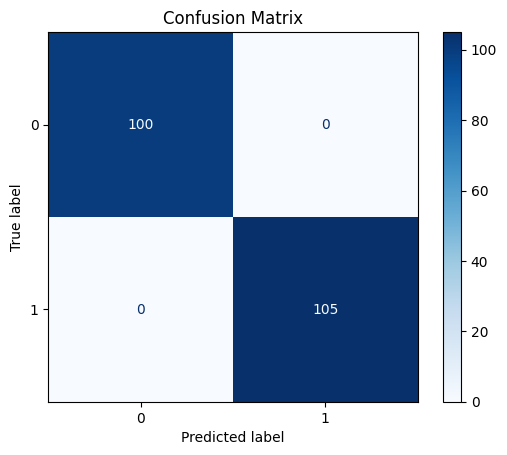

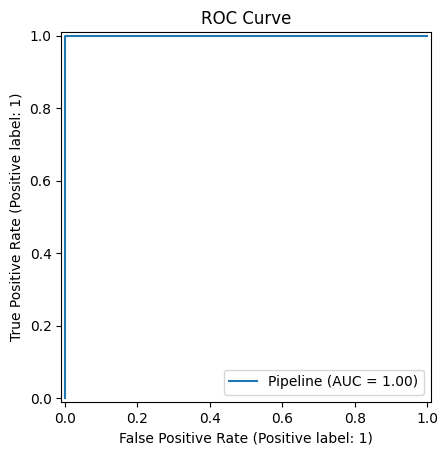

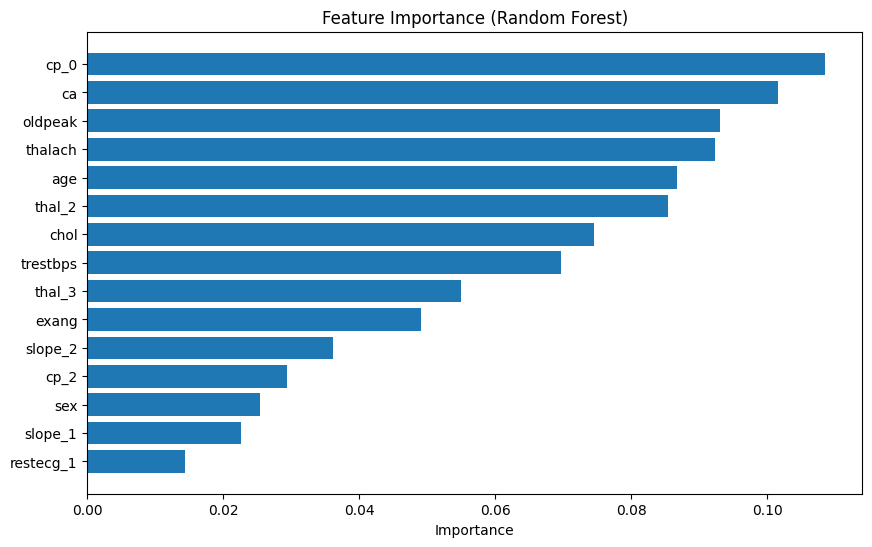

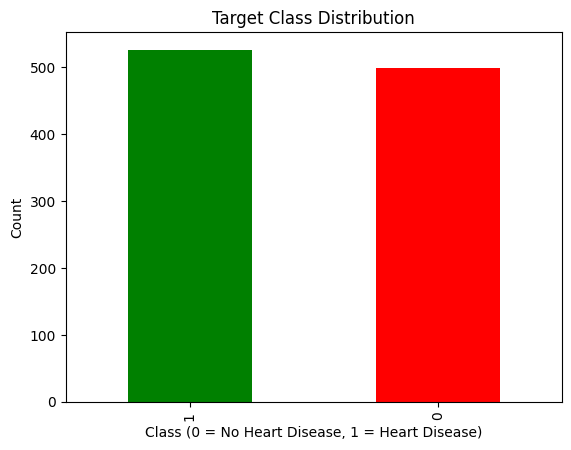

In [20]:
# 🔹 Section 10: Model Insights & Graphs
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

# Get the trained classifier inside the pipeline
model = final_model.steps[-1][1]   # last step (clf)

# 1️⃣ Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    final_model,   # pipeline (preprocessor + clf)
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training Score")
plt.plot(train_sizes, val_mean, 'o-', label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

# 2️⃣ Confusion Matrix
y_pred = final_model.predict(X_test)
cm_disp = ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test, cmap="Blues"
)
plt.title("Confusion Matrix")
plt.show()

# 3️⃣ ROC Curve + AUC (already partly done, but with nicer format)
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

# 4️⃣ Feature Importance (depending on model type)
if best_name == "LogisticRegression":
    importance = model.coef_[0]
    feature_names = schema["features"]

    plt.figure(figsize=(10,6))
    plt.barh(feature_names, importance)
    plt.xlabel("Coefficient Value")
    plt.title("Feature Importance (Logistic Regression Coefficients)")
    plt.show()

elif best_name == "RandomForest":
    importance = model.feature_importances_
    # Get transformed feature names
    feature_names = []
    feature_names.extend(numeric)
    if categorical:
        ohe = final_model.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
        ohe_features = ohe.get_feature_names_out(categorical).tolist()
        feature_names.extend(ohe_features)

    plt.figure(figsize=(10,6))
    idx = np.argsort(importance)[::-1][:15]  # top 15 features
    plt.barh(np.array(feature_names)[idx], importance[idx])
    plt.xlabel("Importance")
    plt.title("Feature Importance (Random Forest)")
    plt.gca().invert_yaxis()
    plt.show()

# 5️⃣ Target Class Distribution
y.value_counts().plot(kind="bar", color=["green","red"])
plt.title("Target Class Distribution")
plt.xlabel("Class (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Count")
plt.show()


Cross-validation accuracy (5-fold): [0.96341463 0.98780488 0.99390244 0.98170732 1.        ]
Mean CV accuracy: 0.9853658536585366


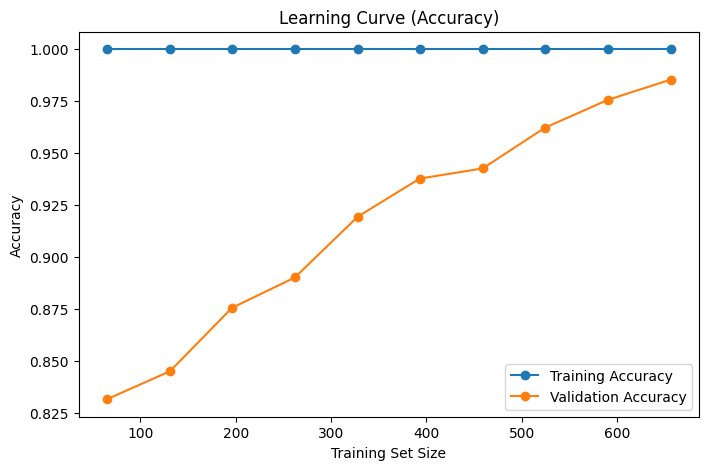

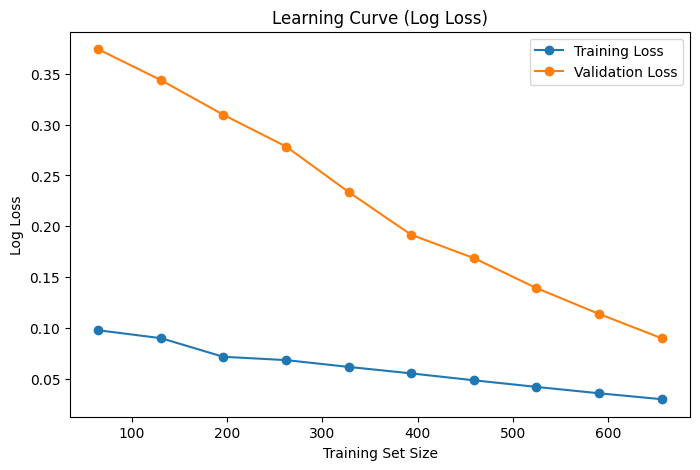

Final Test Accuracy: 1.0
Final Test Log Loss: 0.05570061250855094


In [21]:
# 🔹 Section 10: Model Insights (Accuracy & Loss Curves + Graphs)
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import log_loss

# Get classifier inside pipeline
model = final_model.steps[-1][1]

# 1️⃣ Cross-validation accuracy
cv_scores = cross_val_score(final_model, X_train, y_train, cv=5, scoring="accuracy")
print("Cross-validation accuracy (5-fold):", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# 2️⃣ Learning Curve (Accuracy vs Training Size)
train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Accuracy)")
plt.legend()
plt.show()

# 3️⃣ Log Loss Curve (acts like a 'loss curve')
train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_log_loss",   # use log loss
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Convert negative log loss back to positive
train_loss = -np.mean(train_scores, axis=1)
val_loss = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_loss, 'o-', label="Training Loss")
plt.plot(train_sizes, val_loss, 'o-', label="Validation Loss")
plt.xlabel("Training Set Size")
plt.ylabel("Log Loss")
plt.title("Learning Curve (Log Loss)")
plt.legend()
plt.show()

# 4️⃣ Final Test Set Accuracy & Loss
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_loss = log_loss(y_test, y_proba)

print("Final Test Accuracy:", test_acc)
print("Final Test Log Loss:", test_loss)


In [25]:
import joblib
joblib.dump(final_model, "heart_model.pkl")
print("✅ Model saved as heart_model.pkl")


✅ Model saved as heart_model.pkl
